In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [2]:
omega = 1.8

feature_vec_len = 32
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])

values = np.sin(omega*t+x.T)

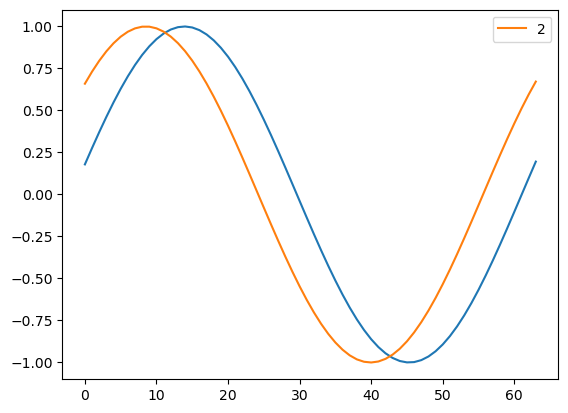

In [3]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [4]:
def get_sample(values, dt=4, inclusion_prob=0.5):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions, positions)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(dt, time_horizon - 2*dt)
    time_to_predict = time_stamp + np.random.randint(1, 2*dt)

    is_included = np.random.random(positions) > inclusion_prob
    for idx, included in zip(range(positions), is_included):
        _time = time_stamp + np.random.randint(-dt, dt)
        sample.append((
            idx/positions,
            included*1.0,
            values[_time, idx] * included,
            _time/64,
            time_to_predict/64,
        ))
        sample_dt.append((
            idx/positions,
            1.0,
            values[time_to_predict, idx],
            time_to_predict/64,
            time_to_predict/64,
        ))

    return (
        torch.tensor(sample, dtype=torch.float32, requires_grad=False),
        torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
        torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [5]:
class feature_encoder(nn.Module):
    def __init__(self, dims=None, output_feature_num=feature_vec_len):
        nn.Module.__init__(self)

        if dims is None:
            self.dims = {
                "time": 1,
                "x_pos": 1,
                "value": 1,
            } 
        else:
            self.dims = dims

        self.input_dimensionality = sum(self.dims.values())

        self.seq = nn.Sequential(
            nn.Linear(self.input_dimensionality, 32),
            nn.GELU(),
            nn.Linear(32, output_feature_num),
            nn.GELU(),
        )

    def forward(self, x):
        return self.seq(x)

In [6]:
fe_model = feature_encoder(dims = {
                "x_pos": 1,
                "value": 1,
                "certaininty": 1,
            } )
te = feature_encoder({'time': 1}, output_feature_num=16)
sample = get_sample(values)
fe_model(sample[0])

/tmp/ipykernel_99218/1968012416.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x5 and 3x32)

In [26]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = feature_vec_len
        edge_params_shape = values.shape[1]**2
        self.fe = feature_encoder(dims={
                "x_pos": 1,
                "value": 1,
                "certaininty": 1,
                "time": 1,
                "prediction_time":1,
            } 
        )
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=feature_vec_len,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self.l2 = nn.Linear(self.gnn_out_ch, 2)

    def forward(self, nodes, edges):
        encoded_features = self.fe(nodes)

        g_output = self.l1(encoded_features, edges, edge_attr=self.edge_params)
        dense_output = self.l2(g_output)

        return dense_output



In [31]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = feature_vec_len
        edge_params_shape = values.shape[1]**2
        self.fe = feature_encoder(dims={
                "x_pos": 1,
                "value": 1,
                "certaininty": 1,
                #"time": 1,
                #"prediction_time":1,
            } 
        )
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=feature_vec_len+2,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self.l2 = nn.Linear(self.gnn_out_ch, 2)

    def forward(self, nodes, edges):
        encoded_features = self.fe(nodes[:,:3])
        #print(encoded_features.shape, nodes[:,3:].shape)
        nodes_input = torch.cat([encoded_features, nodes[:,3:]],dim=1)

        g_output = self.l1(nodes_input, edges, edge_attr=self.edge_params)
        dense_output = self.l2(g_output)

        return dense_output



In [32]:
model = gnn_model()

In [33]:
model(
    sample[0],
    sample[1],
).shape

torch.Size([64, 2])

In [34]:
NUM_TR_STEPS = 1024*32
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-2,)
loss_fn = nn.MSELoss()

for i in range(NUM_TR_STEPS):
    optimizer.zero_grad()
    for _ in range(1):
        sample = get_sample(values)

        y_hat = model(
            sample[0],
            sample[1],
        )

        loss = loss_fn(sample[2][:,-3], y_hat[:,-1])
        
        # check if this is correct place for zero grad
        loss.backward()

    optimizer.step()

    if i%20 == 0:
        l_dt = ((sample[2][:,-3] - y_hat[:,-1])**2).T
        loss_t_dt.append(l_dt.detach())
        print(f"l_dt:{torch.mean(l_dt)}")



/tmp/ipykernel_99218/1968012416.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


l_dt:0.500337541103363
l_dt:0.5017566084861755
l_dt:0.49165278673171997
l_dt:0.49253010749816895
l_dt:0.5088490843772888
l_dt:0.5094044208526611
l_dt:0.5042060017585754
l_dt:0.49080073833465576
l_dt:0.5850120782852173
l_dt:0.5684536695480347
l_dt:0.5349339246749878
l_dt:0.5002479553222656
l_dt:0.4998278319835663
l_dt:0.5000249743461609
l_dt:0.5055020451545715
l_dt:0.49310147762298584
l_dt:0.510080099105835
l_dt:0.49053192138671875
l_dt:0.49874311685562134
l_dt:0.5099119544029236
l_dt:0.5050681233406067
l_dt:0.49187421798706055
l_dt:0.4971768856048584
l_dt:0.5102085471153259
l_dt:0.49104586243629456
l_dt:0.49412956833839417
l_dt:0.5100826025009155
l_dt:0.5084328055381775
l_dt:0.506864070892334
l_dt:0.4900796115398407
l_dt:0.5016862154006958
l_dt:0.4914591610431671
l_dt:0.4938221871852875
l_dt:0.5093032121658325
l_dt:0.49915915727615356
l_dt:0.495161235332489
l_dt:0.49911659955978394
l_dt:0.49388641119003296
l_dt:0.55820232629776
l_dt:0.5298075675964355
l_dt:0.5129734873771667
l_dt:0.523

KeyboardInterrupt: 

In [49]:
torch.mean((
    #y_hat[:,-1:] - sample[2][:,-1:])**2)
    sample[0][:,-1:] - sample[2][:,-1:])**2)

tensor(0.)

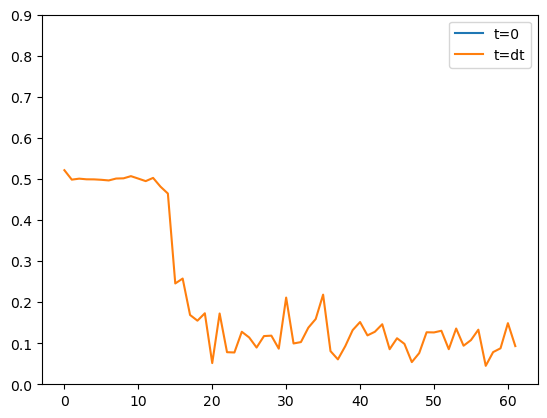

In [77]:
mean_over = 4
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array([torch.mean(x).item() for x in loss_t_dt])
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.9)
plt.show()

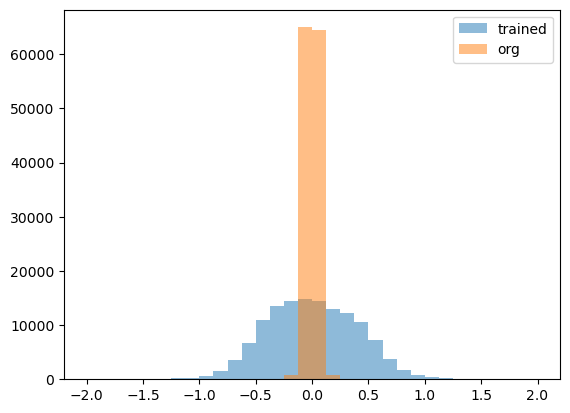

In [74]:
plt.hist(model.edge_params.detach().flatten(), bins=32, label='trained', alpha=0.5,range=(-2,2))
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

/tmp/ipykernel_73694/1968012416.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


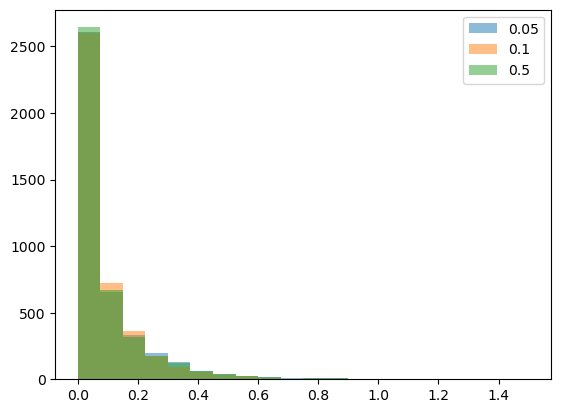

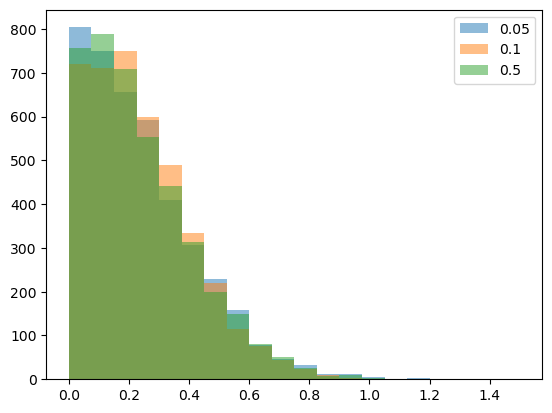

In [75]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=0.2)

            y_hat = model(
                sample[0],
                sample[1],
            )

            l_dt = ((sample[2][:,-3] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()

/tmp/ipykernel_73694/1968012416.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


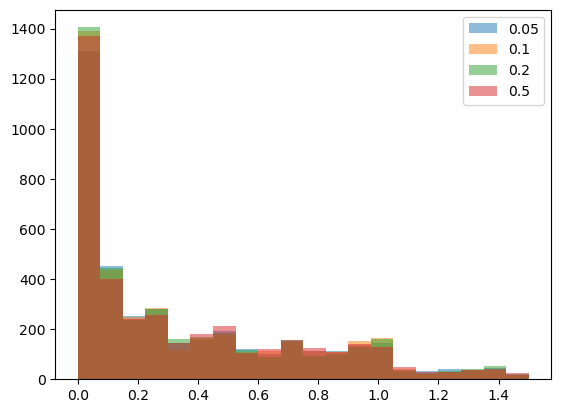

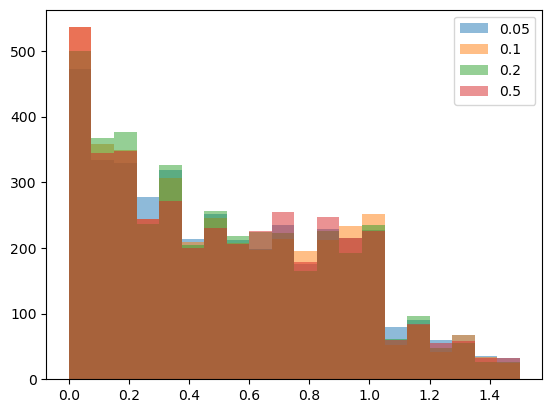

In [76]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=0.2)

            l_dt = ((sample[2][:,-3] - sample[0][:,-3])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()